# Notebook 97 - point spacing and line-aligned fascicle speckle tracking

This notebook extends the three-point fascicle speckle experiment on the validated `june30_4_best` sequence.

It tests two ideas:

1. **More space between the three points.** The center point is selected once, then the back/front points are placed at three center-to-point offsets: `25`, `35`, and `45 px`.
2. **Keep the points aligned with the fascicle.** In addition to normal independent 2D patch tracking, the notebook runs a line-aligned tracker. The center point is tracked normally because it is selected as the best local texture point. The back/front points are then tracked with a 1D ZNCC search along a line parallel to the reference fascicle through the current center point.

The larger `41 x 41 px` texture box is used here because notebook 96 showed the best QC for that box size. The output includes overlay videos for every spacing and mode.


In [1]:
from __future__ import annotations

import json
import os
import sys
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "ultrasound_tracker").exists():
    ROOT = ROOT.parent.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ultrasound_tracker.speckle_confidence import (  # noqa: E402
    SpeckleConfidenceConfig,
    compute_speckle_coherence,
    zncc,
    _gray_float,
    _match_patch_at,
)
from ultrasound_tracker.ultratrack_klt import read_gray_frames  # noqa: E402
from ultrasound_tracker.geometry import line_length_from_array  # noqa: E402

DATASET_NAME = "june30_4_best"
BOX_SIZE = 41
OFFSETS_PX = [25.0, 35.0, 45.0]
SEARCH_RADIUS = 8
LINE_SEARCH_RADIUS = 18.0
LINE_SEARCH_STEP = 1.0

OUT_DIR = ROOT / "results" / DATASET_NAME / "three_point_spacing_line_alignment"
FIG_DIR = OUT_DIR / "figures"
VIDEO_DIR = OUT_DIR / "overlays"
TRACKING_CSV_PATH = OUT_DIR / "spacing_line_alignment_tracking.csv"
SUMMARY_CSV_PATH = OUT_DIR / "spacing_line_alignment_summary.csv"
SUMMARY_JSON_PATH = OUT_DIR / "spacing_line_alignment_summary.json"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
VIDEO_DIR.mkdir(parents=True, exist_ok=True)

POINT_ORDER = ["back", "center", "front"]
POINT_COLORS = {"back": "tab:orange", "center": "tab:cyan", "front": "tab:green"}
MODE_COLORS = {"independent": "tab:blue", "line_aligned": "tab:red"}

CFG = SpeckleConfidenceConfig(
    block_size=BOX_SIZE,
    stride=24,
    search_radius=SEARCH_RADIUS,
    min_texture_variance=5.0,
    zncc_low=0.45,
    zncc_high=0.90,
    forward_backward_scale_px=2.0,
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

print(f"Project root: {ROOT}")
print(f"Texture box: {BOX_SIZE} x {BOX_SIZE} px")
print(f"Offsets: {OFFSETS_PX}")
print(f"Outputs: {OUT_DIR}")


Project root: /Users/grosbedou/PycharmProjects/NDORMS
Texture box: 41 x 41 px
Offsets: [25.0, 35.0, 45.0]
Outputs: /Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_spacing_line_alignment


## Load the validated sequence


In [2]:
def resolve_existing_path(value, fallback: Path | None = None) -> Path:
    candidates = []
    if value:
        p = Path(str(value)).expanduser()
        candidates.append(p if p.is_absolute() else ROOT / p)
        candidates.append(ROOT / p.name)
    if fallback is not None:
        candidates.append(fallback)
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    if candidates:
        return candidates[0].resolve()
    raise FileNotFoundError("No path candidate supplied.")


def find_validated_run_dir(name: str) -> Path:
    primary = ROOT / "results" / "strict_ultratimtrack_runs" / name
    if (primary / f"{name}_strict_results.npz").exists():
        return primary.resolve()
    for npz_path in sorted((ROOT / "results").glob(f"**/{name}_strict_results.npz")):
        return npz_path.parent.resolve()
    raise FileNotFoundError(f"Could not find strict results for {name}.")


def finite_scalar(value, default=np.nan) -> float:
    try:
        arr = np.asarray(value, dtype=np.float64).reshape(-1)
        if arr.size and np.isfinite(arr[0]):
            return float(arr[0])
    except Exception:
        pass
    return float(default)


def video_fps_and_count(path: Path) -> tuple[float, int]:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise FileNotFoundError(path)
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return fps, n_frames


STRICT_RUN_DIR = find_validated_run_dir(DATASET_NAME)
NPZ_PATH = STRICT_RUN_DIR / f"{DATASET_NAME}_strict_results.npz"
METADATA_PATH = STRICT_RUN_DIR / f"{DATASET_NAME}_strict_metadata.json"

metadata = json.loads(METADATA_PATH.read_text()) if METADATA_PATH.exists() else {}
with np.load(NPZ_PATH, allow_pickle=True) as npz:
    arrays = {key: npz[key] for key in npz.files}

VIDEO_PATH = resolve_existing_path(metadata.get("video"), ROOT / "data" / "raw" / f"{DATASET_NAME}.AVI")
ROI_PATH = resolve_existing_path(metadata.get("roi_path"), ROOT / "data" / "rois" / f"{DATASET_NAME}_rois.json")
rois = json.loads(ROI_PATH.read_text()) if ROI_PATH.exists() else {}

fps_cv2, n_video_frames = video_fps_and_count(VIDEO_PATH)
fps = finite_scalar(metadata.get("fps", np.nan), default=fps_cv2)
if not np.isfinite(fps) or fps <= 0:
    fps = fps_cv2 if fps_cv2 > 0 else np.nan

n_from_results = int(np.asarray(arrays.get("frame", [])).reshape(-1).size)
n_to_load = n_from_results if n_from_results > 0 else n_video_frames
frames = read_gray_frames(VIDEO_PATH, limit=n_to_load)
if not frames:
    raise RuntimeError(f"No frames were read from {VIDEO_PATH}")

frame_shape = frames[0].shape[:2]
time_s = np.arange(len(frames), dtype=np.float64) / fps if np.isfinite(fps) and fps > 0 else np.full(len(frames), np.nan)
mm_per_pixel = finite_scalar(arrays.get("mm_per_pixel", metadata.get("mm_per_pixel", np.nan)))
has_mm_calibration = bool(np.isfinite(mm_per_pixel) and mm_per_pixel > 0)
fascicle_roi = tuple(int(v) for v in rois.get("fascicle", (0, 0, frame_shape[1], frame_shape[0])))

print(f"Strict run: {STRICT_RUN_DIR}")
print(f"Video: {VIDEO_PATH}")
print(f"Frames loaded: {len(frames)}; fps={fps}")
print(f"Frame shape: {frame_shape}; fascicle ROI={fascicle_roi}")
print(f"mm_per_pixel: {mm_per_pixel if has_mm_calibration else 'not found'}")


Strict run: /Users/grosbedou/PycharmProjects/NDORMS/results/strict_ultratimtrack_runs/june30_4_best
Video: /Users/grosbedou/PycharmProjects/NDORMS/data/raw/june30_4_best.AVI
Frames loaded: 84; fps=11.0
Frame shape: (800, 800); fascicle ROI=(180, 107, 442, 228)
mm_per_pixel: 0.063375


## Reference fascicle and patch helpers


In [3]:
ONE_BASED_OFFSET = np.array([1.0, 1.0, 1.0, 1.0], dtype=np.float64)


def finite_segment(segment) -> bool:
    arr = np.asarray(segment, dtype=np.float64).reshape(-1)
    return arr.size >= 4 and np.all(np.isfinite(arr[:4])) and line_length_from_array(arr[:4]) > 1.0


def reference_fascicle_segment_zero_based(frame_idx: int = 0) -> tuple[np.ndarray, str]:
    for key in ["fascicle_end_segments", "fascicle_segments", "forward_fascicle_end_segments", "selected_seed_segment"]:
        if key not in arrays:
            continue
        arr = np.asarray(arrays[key], dtype=np.float64)
        if arr.ndim == 2 and arr.shape[1] >= 4 and frame_idx < arr.shape[0]:
            seg = arr[frame_idx, :4]
        elif arr.ndim == 1 and arr.size >= 4:
            seg = arr[:4]
        else:
            continue
        if finite_segment(seg):
            return seg - ONE_BASED_OFFSET, key
    meta_seg = metadata.get("selected_seed_segment")
    if meta_seg is not None and finite_segment(meta_seg):
        return np.asarray(meta_seg, dtype=np.float64) - ONE_BASED_OFFSET, "metadata.selected_seed_segment"
    raise RuntimeError("No usable saved fascicle segment found.")


def line_from_array_zero_based(key: str, frame_idx: int = 0) -> np.ndarray | None:
    if key not in arrays:
        return None
    arr = np.asarray(arrays[key], dtype=np.float64)
    if arr.ndim != 2 or frame_idx >= arr.shape[0] or arr.shape[1] < 4:
        return None
    seg = arr[frame_idx, :4]
    if not finite_segment(seg):
        return None
    return seg - ONE_BASED_OFFSET


fascicle_line0, fascicle_source = reference_fascicle_segment_zero_based(0)
p0 = fascicle_line0[:2].astype(np.float64)
p1 = fascicle_line0[2:4].astype(np.float64)
fascicle_length_px = float(np.linalg.norm(p1 - p0))
t_hat = (p1 - p0) / fascicle_length_px
n_hat = np.array([-t_hat[1], t_hat[0]], dtype=np.float64)

sup_apo0 = line_from_array_zero_based("sup_apo_lines", 0)
deep_apo0 = line_from_array_zero_based("deep_apo_lines", 0)


def extract_patch(frame: np.ndarray, point: np.ndarray, block_size: int) -> np.ndarray | None:
    gray = _gray_float(frame)
    half = int(block_size) // 2
    x, y = np.rint(np.asarray(point, dtype=np.float64)).astype(int)
    if x - half < 0 or x + half + 1 > gray.shape[1]:
        return None
    if y - half < 0 or y + half + 1 > gray.shape[0]:
        return None
    return gray[y - half : y + half + 1, x - half : x + half + 1]


def point_to_line_distance(point: np.ndarray, line: np.ndarray) -> float:
    point = np.asarray(point, dtype=np.float64).reshape(2)
    line = np.asarray(line, dtype=np.float64).reshape(4)
    a = line[:2]
    b = line[2:]
    denom = float(np.linalg.norm(b - a))
    if denom <= 1e-12:
        return float("nan")
    return float(abs(np.cross(b - a, point - a)) / denom)


def point_in_roi(point: np.ndarray, roi: tuple[int, int, int, int] | None, margin: float = 0.0) -> bool:
    if roi is None:
        return True
    x, y = [float(v) for v in np.asarray(point).reshape(2)]
    rx, ry, rw, rh = [float(v) for v in roi]
    return (rx + margin) <= x <= (rx + rw - margin) and (ry + margin) <= y <= (ry + rh - margin)


def valid_patch_center(
    point: np.ndarray,
    shape: tuple[int, int],
    cfg: SpeckleConfidenceConfig,
    roi: tuple[int, int, int, int] | None = None,
    aponeurosis_lines: list[np.ndarray | None] | None = None,
) -> bool:
    point = np.asarray(point, dtype=np.float64).reshape(2)
    if not np.all(np.isfinite(point)):
        return False
    half = int(cfg.block_size) // 2
    radius = int(cfg.search_radius)
    margin = half + radius
    height, width = int(shape[0]), int(shape[1])
    x, y = point
    if not (margin <= x <= width - 1 - margin and margin <= y <= height - 1 - margin):
        return False
    if roi is not None and not point_in_roi(point, roi, margin=half):
        return False
    if aponeurosis_lines:
        apo_margin = float(half + 2)
        for line in aponeurosis_lines:
            if line is not None and point_to_line_distance(point, line) < apo_margin:
                return False
    return True


def match_point_once(prev_frame: np.ndarray, curr_frame: np.ndarray, point: np.ndarray, cfg: SpeckleConfidenceConfig) -> dict:
    prev = _gray_float(prev_frame)
    curr = _gray_float(curr_frame)
    forward = _match_patch_at(prev, curr, point, cfg)
    if forward is None:
        return {"ok": False, "point": np.full(2, np.nan), "zncc": np.nan, "cv_score": np.nan}

    matched_point, cv_score = forward
    template = extract_patch(prev, point, int(cfg.block_size))
    matched_patch = extract_patch(curr, matched_point, int(cfg.block_size))
    z = float("nan")
    if template is not None and matched_patch is not None:
        z = zncc(template, matched_patch, min_texture_variance=float(cfg.min_texture_variance))
    if not np.isfinite(z):
        z = float(cv_score)
    return {"ok": True, "point": np.asarray(matched_point, dtype=np.float64), "zncc": float(z), "cv_score": float(cv_score)}


def match_point_with_fb(prev_frame: np.ndarray, curr_frame: np.ndarray, point: np.ndarray, cfg: SpeckleConfidenceConfig) -> dict:
    forward = match_point_once(prev_frame, curr_frame, point, cfg)
    if not forward["ok"]:
        return {**forward, "forward_backward_error": np.nan}
    reverse = match_point_once(curr_frame, prev_frame, forward["point"], cfg)
    if reverse["ok"]:
        fb_error = float(np.linalg.norm(reverse["point"] - np.asarray(point, dtype=np.float64).reshape(2)))
    else:
        fb_error = float("nan")
    return {**forward, "forward_backward_error": fb_error}

print(f"Reference fascicle source: {fascicle_source}")
print(f"fascicle_length_px={fascicle_length_px:.2f}")
print(f"t_hat={t_hat}, n_hat={n_hat}")


Reference fascicle source: fascicle_end_segments
fascicle_length_px=1139.51
t_hat=[-0.97437006  0.22495106], n_hat=[-0.22495106 -0.97437006]


## Select one center point, then build three spacings


In [4]:
def candidate_score_table(frame0, frame1, line, cfg, roi, n_samples=141) -> pd.DataFrame:
    line = np.asarray(line, dtype=np.float64).reshape(4)
    p_start = line[:2]
    p_end = line[2:]
    fractions = np.linspace(0.15, 0.85, int(n_samples))
    rows = []
    apo_lines = [sup_apo0, deep_apo0]
    for fraction in fractions:
        point = p_start + fraction * (p_end - p_start)
        if not valid_patch_center(point, frame0.shape[:2], cfg, roi=roi, aponeurosis_lines=apo_lines):
            continue
        patch = extract_patch(frame0, point, int(cfg.block_size))
        if patch is None:
            continue
        match = match_point_once(frame0, frame1, point, cfg)
        rows.append(
            {
                "fraction": float(fraction),
                "x": float(point[0]),
                "y": float(point[1]),
                "texture_variance": float(np.var(patch)),
                "zncc_0_1": float(match["zncc"]),
            }
        )
    table = pd.DataFrame(rows)
    if table.empty:
        raise RuntimeError("No valid center candidates found.")
    q10, q90 = table["texture_variance"].quantile([0.10, 0.90])
    table["texture_score"] = ((table["texture_variance"] - float(q10)) / max(float(q90 - q10), 1e-12)).clip(0, 1)
    table["zncc_score"] = ((table["zncc_0_1"] - CFG.zncc_low) / max(CFG.zncc_high - CFG.zncc_low, 1e-12)).clip(0, 1)
    table.loc[~np.isfinite(table["zncc_score"]), "zncc_score"] = 0.0
    table["combined_score"] = 0.45 * table["texture_score"] + 0.55 * table["zncc_score"]
    return table.sort_values("combined_score", ascending=False).reset_index(drop=True)


def points_for_offset(center: np.ndarray, offset_px: float) -> dict[str, np.ndarray]:
    return {
        "back": center - float(offset_px) * t_hat,
        "center": center.copy(),
        "front": center + float(offset_px) * t_hat,
    }


center_candidates = candidate_score_table(frames[0], frames[1], fascicle_line0, CFG, fascicle_roi)
center_point = center_candidates.iloc[0][["x", "y"]].to_numpy(dtype=np.float64)
center_candidates.to_csv(OUT_DIR / "center_candidate_scores.csv", index=False)

initial_points_by_offset: dict[float, dict[str, np.ndarray]] = {}
for offset in OFFSETS_PX:
    points = points_for_offset(center_point, offset)
    for point_id, point in points.items():
        if not valid_patch_center(point, frame_shape, CFG, roi=fascicle_roi, aponeurosis_lines=[sup_apo0, deep_apo0]):
            raise RuntimeError(f"{point_id} at offset {offset}px is not valid for the {BOX_SIZE}px texture box.")
    initial_points_by_offset[float(offset)] = points

print(f"Selected center point: {center_point}")
for offset, points in initial_points_by_offset.items():
    print(f"offset={offset:.0f}px, back-front initial spacing={2 * offset:.0f}px")
    for point_id in POINT_ORDER:
        print(f"  {point_id:>6}: {points[point_id]}")
display(center_candidates.head(8))


Selected center point: [337.9332249  230.43132496]
offset=25px, back-front initial spacing=50px
    back: [362.2924765  224.80754852]
  center: [337.9332249  230.43132496]
   front: [313.5739733  236.05510141]
offset=35px, back-front initial spacing=70px
    back: [372.03617714 222.55803794]
  center: [337.9332249  230.43132496]
   front: [303.83027266 238.30461199]
offset=45px, back-front initial spacing=90px
    back: [381.77987778 220.30852736]
  center: [337.9332249  230.43132496]
   front: [294.08657202 240.55412256]


/var/folders/xv/1j8r4j6525v2s3svp0bnsy1w0000gn/T/ipykernel_89189/2595128067.py:70: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(abs(np.cross(b - a, point - a)) / denom)
/var/folders/xv/1j8r4j6525v2s3svp0bnsy1w0000gn/T/ipykernel_89189/2595128067.py:70: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(abs(np.cross(b - a, point - a)) / denom)


,fraction,x,y,texture_variance,zncc_0_1,texture_score,zncc_score,combined_score
0,0.555,337.933225,230.431325,1435.485474,0.987626,1.0,1.0,1.0
1,0.550,343.484750,229.149654,1457.544556,0.987937,1.0,1.0,1.0
2,0.545,349.036274,227.867984,1389.526611,0.987970,1.0,1.0,1.0
3,0.575,315.727126,235.558007,1375.984741,0.984083,1.0,1.0,1.0
4,0.580,310.175601,236.839677,1443.360229,0.985430,1.0,1.0,1.0
5,0.585,304.624076,238.121348,1519.092407,0.986177,1.0,1.0,1.0
6,0.590,299.072551,239.403019,1564.272705,0.986301,1.0,1.0,1.0
7,0.595,293.521027,240.684689,1469.464722,0.985591,1.0,1.0,1.0


## Tracking implementations

`independent`: same 2D patch tracker as notebook 95/96.

`line_aligned`: center point is tracked normally. Back/front are searched in 1D along a line through the current center with the same angle as the reference fascicle. This preserves a variable longitudinal spacing while removing perpendicular wandering of the outer points.


In [5]:
def line_candidate_point(center: np.ndarray, signed_offset: float) -> np.ndarray:
    return np.asarray(center, dtype=np.float64).reshape(2) + float(signed_offset) * t_hat


def line_match_once(
    prev_frame: np.ndarray,
    curr_frame: np.ndarray,
    prev_point: np.ndarray,
    curr_center: np.ndarray,
    signed_offset_guess: float,
    cfg: SpeckleConfidenceConfig,
    search_radius: float = LINE_SEARCH_RADIUS,
    step: float = LINE_SEARCH_STEP,
) -> dict:
    template = extract_patch(prev_frame, prev_point, int(cfg.block_size))
    if template is None or float(np.var(template)) < float(cfg.min_texture_variance):
        return {"ok": False, "point": np.full(2, np.nan), "signed_offset": np.nan, "zncc": np.nan}

    offsets = np.arange(float(signed_offset_guess) - search_radius, float(signed_offset_guess) + search_radius + 0.5 * step, step)
    best_score = -np.inf
    best_point = None
    best_offset = np.nan
    for signed_offset in offsets:
        candidate = line_candidate_point(curr_center, signed_offset)
        if not valid_patch_center(candidate, frame_shape, cfg):
            continue
        patch = extract_patch(curr_frame, candidate, int(cfg.block_size))
        if patch is None:
            continue
        score = zncc(template, patch, min_texture_variance=float(cfg.min_texture_variance))
        if np.isfinite(score) and float(score) > best_score:
            best_score = float(score)
            best_point = candidate
            best_offset = float(signed_offset)

    if best_point is None:
        return {"ok": False, "point": np.full(2, np.nan), "signed_offset": np.nan, "zncc": np.nan}
    return {"ok": True, "point": np.asarray(best_point, dtype=np.float64), "signed_offset": best_offset, "zncc": best_score}


def line_match_with_fb(prev_frame, curr_frame, prev_point, prev_center, curr_center, signed_offset_guess, cfg):
    forward = line_match_once(prev_frame, curr_frame, prev_point, curr_center, signed_offset_guess, cfg)
    if not forward["ok"]:
        return {**forward, "forward_backward_error": np.nan}
    reverse = line_match_once(curr_frame, prev_frame, forward["point"], prev_center, forward["signed_offset"], cfg)
    if reverse["ok"]:
        fb_error = float(np.linalg.norm(reverse["point"] - np.asarray(prev_point, dtype=np.float64).reshape(2)))
    else:
        fb_error = float("nan")
    return {**forward, "forward_backward_error": fb_error}


def track_independent(frames_in, points0, cfg):
    n_frames = len(frames_in)
    n_points = len(POINT_ORDER)
    positions = np.full((n_frames, n_points, 2), np.nan, dtype=np.float64)
    dxdy = np.zeros((n_frames, n_points, 2), dtype=np.float64)
    zncc_scores = np.full((n_frames, n_points), np.nan, dtype=np.float64)
    fb_errors = np.full((n_frames, n_points), np.nan, dtype=np.float64)
    valid = np.zeros((n_frames, n_points), dtype=bool)
    fallback_used = np.zeros((n_frames, n_points), dtype=bool)
    signed_offsets = np.full((n_frames, n_points), np.nan, dtype=np.float64)

    for point_idx, point_id in enumerate(POINT_ORDER):
        positions[0, point_idx] = np.asarray(points0[point_id], dtype=np.float64)
        valid[0, point_idx] = True
    signed_offsets[0] = [np.dot(positions[0, i] - positions[0, 1], t_hat) for i in range(n_points)]

    last_median_disp = np.zeros(2, dtype=np.float64)
    for frame_idx in range(n_frames - 1):
        attempted_positions = np.full((n_points, 2), np.nan, dtype=np.float64)
        attempted_displacements = np.full((n_points, 2), np.nan, dtype=np.float64)
        pair_good = np.zeros(n_points, dtype=bool)
        for point_idx in range(n_points):
            prev_point = positions[frame_idx, point_idx]
            if not valid_patch_center(prev_point, frames_in[frame_idx].shape[:2], cfg):
                continue
            match = match_point_with_fb(frames_in[frame_idx], frames_in[frame_idx + 1], prev_point, cfg)
            zncc_scores[frame_idx + 1, point_idx] = float(match["zncc"])
            fb_errors[frame_idx + 1, point_idx] = float(match["forward_backward_error"])
            if not match["ok"]:
                continue
            next_point = np.asarray(match["point"], dtype=np.float64)
            disp = next_point - prev_point
            attempted_positions[point_idx] = next_point
            attempted_displacements[point_idx] = disp
            fb_ok = (not np.isfinite(match["forward_backward_error"])) or float(match["forward_backward_error"]) <= cfg.forward_backward_scale_px
            pair_good[point_idx] = bool(float(match["zncc"]) >= cfg.zncc_low and fb_ok)

        if np.any(pair_good):
            fallback_disp = np.nanmedian(attempted_displacements[pair_good], axis=0)
            last_median_disp = fallback_disp.copy()
        else:
            fallback_disp = last_median_disp.copy()
        for point_idx in range(n_points):
            if pair_good[point_idx]:
                positions[frame_idx + 1, point_idx] = attempted_positions[point_idx]
                dxdy[frame_idx + 1, point_idx] = attempted_displacements[point_idx]
                valid[frame_idx + 1, point_idx] = True
            else:
                positions[frame_idx + 1, point_idx] = positions[frame_idx, point_idx] + fallback_disp
                dxdy[frame_idx + 1, point_idx] = fallback_disp
                valid[frame_idx + 1, point_idx] = False
                fallback_used[frame_idx + 1, point_idx] = True
        signed_offsets[frame_idx + 1] = [np.dot(positions[frame_idx + 1, i] - positions[frame_idx + 1, 1], t_hat) for i in range(n_points)]

    return {
        "positions": positions,
        "dxdy": dxdy,
        "zncc": zncc_scores,
        "forward_backward_error": fb_errors,
        "valid": valid,
        "fallback_used": fallback_used,
        "signed_offsets": signed_offsets,
    }


def track_line_aligned(frames_in, points0, cfg):
    n_frames = len(frames_in)
    n_points = len(POINT_ORDER)
    positions = np.full((n_frames, n_points, 2), np.nan, dtype=np.float64)
    dxdy = np.zeros((n_frames, n_points, 2), dtype=np.float64)
    zncc_scores = np.full((n_frames, n_points), np.nan, dtype=np.float64)
    fb_errors = np.full((n_frames, n_points), np.nan, dtype=np.float64)
    valid = np.zeros((n_frames, n_points), dtype=bool)
    fallback_used = np.zeros((n_frames, n_points), dtype=bool)
    signed_offsets = np.full((n_frames, n_points), np.nan, dtype=np.float64)

    for point_idx, point_id in enumerate(POINT_ORDER):
        positions[0, point_idx] = np.asarray(points0[point_id], dtype=np.float64)
        valid[0, point_idx] = True
    signed_offsets[0] = [np.dot(positions[0, i] - positions[0, 1], t_hat) for i in range(n_points)]
    last_center_disp = np.zeros(2, dtype=np.float64)

    for frame_idx in range(n_frames - 1):
        prev_center = positions[frame_idx, POINT_ORDER.index("center")]
        center_match = match_point_with_fb(frames_in[frame_idx], frames_in[frame_idx + 1], prev_center, cfg)
        center_idx = POINT_ORDER.index("center")
        zncc_scores[frame_idx + 1, center_idx] = float(center_match["zncc"])
        fb_errors[frame_idx + 1, center_idx] = float(center_match["forward_backward_error"])
        center_fb_ok = (not np.isfinite(center_match["forward_backward_error"])) or float(center_match["forward_backward_error"]) <= cfg.forward_backward_scale_px
        center_good = bool(center_match["ok"] and float(center_match["zncc"]) >= cfg.zncc_low and center_fb_ok)
        if center_good:
            curr_center = np.asarray(center_match["point"], dtype=np.float64)
            center_disp = curr_center - prev_center
            last_center_disp = center_disp.copy()
            valid[frame_idx + 1, center_idx] = True
        else:
            curr_center = prev_center + last_center_disp
            center_disp = last_center_disp.copy()
            valid[frame_idx + 1, center_idx] = False
            fallback_used[frame_idx + 1, center_idx] = True

        positions[frame_idx + 1, center_idx] = curr_center
        dxdy[frame_idx + 1, center_idx] = center_disp
        signed_offsets[frame_idx + 1, center_idx] = 0.0

        for point_id in ["back", "front"]:
            point_idx = POINT_ORDER.index(point_id)
            prev_point = positions[frame_idx, point_idx]
            prev_signed = float(signed_offsets[frame_idx, point_idx])
            match = line_match_with_fb(
                frames_in[frame_idx],
                frames_in[frame_idx + 1],
                prev_point,
                prev_center,
                curr_center,
                prev_signed,
                cfg,
            )
            zncc_scores[frame_idx + 1, point_idx] = float(match["zncc"])
            fb_errors[frame_idx + 1, point_idx] = float(match["forward_backward_error"])
            fb_ok = (not np.isfinite(match["forward_backward_error"])) or float(match["forward_backward_error"]) <= cfg.forward_backward_scale_px
            point_good = bool(match["ok"] and float(match["zncc"]) >= cfg.zncc_low and fb_ok)
            if point_good:
                curr_point = np.asarray(match["point"], dtype=np.float64)
                curr_signed = float(match["signed_offset"])
                valid[frame_idx + 1, point_idx] = True
            else:
                curr_signed = prev_signed
                curr_point = line_candidate_point(curr_center, curr_signed)
                valid[frame_idx + 1, point_idx] = False
                fallback_used[frame_idx + 1, point_idx] = True
            positions[frame_idx + 1, point_idx] = curr_point
            dxdy[frame_idx + 1, point_idx] = curr_point - prev_point
            signed_offsets[frame_idx + 1, point_idx] = curr_signed

    return {
        "positions": positions,
        "dxdy": dxdy,
        "zncc": zncc_scores,
        "forward_backward_error": fb_errors,
        "valid": valid,
        "fallback_used": fallback_used,
        "signed_offsets": signed_offsets,
    }


def strain_series(positions: np.ndarray) -> pd.DataFrame:
    back = positions[:, POINT_ORDER.index("back"), :]
    center = positions[:, POINT_ORDER.index("center"), :]
    front = positions[:, POINT_ORDER.index("front"), :]
    lengths = {
        "back_front": np.sum((front - back) * t_hat[None, :], axis=1),
        "back_center": np.sum((center - back) * t_hat[None, :], axis=1),
        "center_front": np.sum((front - center) * t_hat[None, :], axis=1),
    }
    out = pd.DataFrame({"frame": np.arange(positions.shape[0], dtype=int)})
    for name, values in lengths.items():
        initial_length = float(values[0])
        out[f"length_{name}_px"] = values
        # Negative strain means shortening; positive strain means lengthening.
        out[f"strain_{name}_percent"] = ((values - initial_length) / initial_length) * 100.0 if abs(initial_length) > 1e-12 else np.nan
    return out


def tracking_dataframe(tracking, mode, offset_px):
    positions = tracking["positions"]
    dxdy = tracking["dxdy"]
    cumulative = positions - positions[0:1, :, :]
    strain = strain_series(positions).set_index("frame")
    rows = []
    for frame_idx in range(positions.shape[0]):
        strain_row = strain.loc[frame_idx]
        for point_idx, point_id in enumerate(POINT_ORDER):
            cum = cumulative[frame_idx, point_idx]
            step = dxdy[frame_idx, point_idx]
            row = {
                "mode": mode,
                "offset_px": float(offset_px),
                "box_size_px": BOX_SIZE,
                "frame": int(frame_idx),
                "time_s": float(time_s[frame_idx]) if frame_idx < len(time_s) else np.nan,
                "point_id": point_id,
                "x": float(positions[frame_idx, point_idx, 0]),
                "y": float(positions[frame_idx, point_idx, 1]),
                "dx": float(step[0]),
                "dy": float(step[1]),
                "cumulative_dx": float(cum[0]),
                "cumulative_dy": float(cum[1]),
                "d_parallel_px": float(np.dot(cum, t_hat)),
                "d_perpendicular_px": float(np.dot(cum, n_hat)),
                "signed_offset_px": float(tracking["signed_offsets"][frame_idx, point_idx]),
                "zncc": float(tracking["zncc"][frame_idx, point_idx]),
                "forward_backward_error": float(tracking["forward_backward_error"][frame_idx, point_idx]),
                "valid": bool(tracking["valid"][frame_idx, point_idx]),
                "fallback_used": bool(tracking["fallback_used"][frame_idx, point_idx]),
                "strain_back_front_percent": float(strain_row["strain_back_front_percent"]),
                "strain_back_center_percent": float(strain_row["strain_back_center_percent"]),
                "strain_center_front_percent": float(strain_row["strain_center_front_percent"]),
            }
            if has_mm_calibration:
                row.update(
                    {
                        "dx_mm": float(step[0] * mm_per_pixel),
                        "dy_mm": float(step[1] * mm_per_pixel),
                        "cumulative_dx_mm": float(cum[0] * mm_per_pixel),
                        "cumulative_dy_mm": float(cum[1] * mm_per_pixel),
                        "d_parallel_mm": float(np.dot(cum, t_hat) * mm_per_pixel),
                        "d_perpendicular_mm": float(np.dot(cum, n_hat) * mm_per_pixel),
                    }
                )
            rows.append(row)
    return pd.DataFrame(rows)


## Run all variants


In [6]:
experiments = {}
dfs = []
summary_rows = []

for offset, points0 in initial_points_by_offset.items():
    for mode in ["independent", "line_aligned"]:
        print(f"Running {mode}, offset={offset:.0f}px...")
        tracking = track_independent(frames, points0, CFG) if mode == "independent" else track_line_aligned(frames, points0, CFG)
        strain = strain_series(tracking["positions"])
        df = tracking_dataframe(tracking, mode, offset)
        experiments[(mode, offset)] = {"tracking": tracking, "strain": strain, "df": df, "points0": points0}
        dfs.append(df)

        invalid_rows = int((~df["valid"]).sum())
        fallback_rows = int(df["fallback_used"].sum())
        invalid_frames = int(df.loc[(~df["valid"]) | df["fallback_used"], "frame"].nunique())
        outer_angle = np.degrees(
            np.arctan2(
                tracking["positions"][:, POINT_ORDER.index("front"), 1] - tracking["positions"][:, POINT_ORDER.index("back"), 1],
                tracking["positions"][:, POINT_ORDER.index("front"), 0] - tracking["positions"][:, POINT_ORDER.index("back"), 0],
            )
        )
        reference_image_angle = np.degrees(np.arctan2(t_hat[1], t_hat[0]))
        angle_error = ((outer_angle - reference_image_angle + 90.0) % 180.0) - 90.0
        summary_rows.append(
            {
                "mode": mode,
                "offset_px": float(offset),
                "initial_back_front_spacing_px": float(2 * offset),
                "mean_zncc": float(df["zncc"].mean(skipna=True)),
                "median_zncc": float(df["zncc"].median(skipna=True)),
                "invalid_rows": invalid_rows,
                "fallback_rows": fallback_rows,
                "invalid_frames": invalid_frames,
                "max_cumulative_displacement_px": float(np.nanmax(np.hypot(df["cumulative_dx"], df["cumulative_dy"]))),
                "peak_abs_longitudinal_strain_percent": float(np.nanmax(np.abs(strain["strain_back_front_percent"]))),
                "peak_longitudinal_strain_percent": float(strain["strain_back_front_percent"].iloc[np.nanargmax(np.abs(strain["strain_back_front_percent"]))]),
                "outer_line_angle_error_deg_median_abs": float(np.nanmedian(np.abs(angle_error))),
                "outer_line_angle_error_deg_q90_abs": float(np.nanquantile(np.abs(angle_error), 0.90)),
            }
        )

tracking_df = pd.concat(dfs, ignore_index=True)
summary_df = pd.DataFrame(summary_rows).sort_values(["offset_px", "mode"]).reset_index(drop=True)
tracking_df.to_csv(TRACKING_CSV_PATH, index=False)
summary_df.to_csv(SUMMARY_CSV_PATH, index=False)
SUMMARY_JSON_PATH.write_text(json.dumps(summary_df.to_dict(orient="records"), indent=2))

print(f"Saved tracking CSV: {TRACKING_CSV_PATH}")
print(f"Saved summary CSV: {SUMMARY_CSV_PATH}")
display(summary_df)


Running independent, offset=25px...


Running line_aligned, offset=25px...


Running independent, offset=35px...


Running line_aligned, offset=35px...


Running independent, offset=45px...


Running line_aligned, offset=45px...


Saved tracking CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_spacing_line_alignment/spacing_line_alignment_tracking.csv
Saved summary CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_spacing_line_alignment/spacing_line_alignment_summary.csv


,mode,offset_px,initial_back_front_spacing_px,mean_zncc,median_zncc,invalid_rows,fallback_rows,invalid_frames,max_cumulative_displacement_px,peak_abs_longitudinal_strain_percent,peak_longitudinal_strain_percent,outer_line_angle_error_deg_median_abs,outer_line_angle_error_deg_q90_abs
0,independent,25.0,50.0,0.912676,0.926863,29,29,21,74.883842,36.715087,36.715087,2.524111e+00,3.601088e+00
1,line_aligned,25.0,50.0,0.900458,0.923213,44,44,33,52.008761,30.000000,-30.000000,0.000000e+00,2.842171e-14
2,independent,35.0,70.0,0.894562,0.921197,26,26,19,63.734092,39.786523,39.786523,3.208647e+00,4.780791e+00
3,line_aligned,35.0,70.0,0.889820,0.920977,42,42,32,55.978444,41.428571,-41.428571,2.842171e-14,2.842171e-14
4,independent,45.0,90.0,0.900049,0.921772,30,30,25,65.313336,29.210396,-29.210396,2.018855e+00,3.771224e+00
5,line_aligned,45.0,90.0,0.883747,0.921716,46,46,34,75.007010,32.222222,-32.222222,0.000000e+00,2.842171e-14


## Static comparison figures


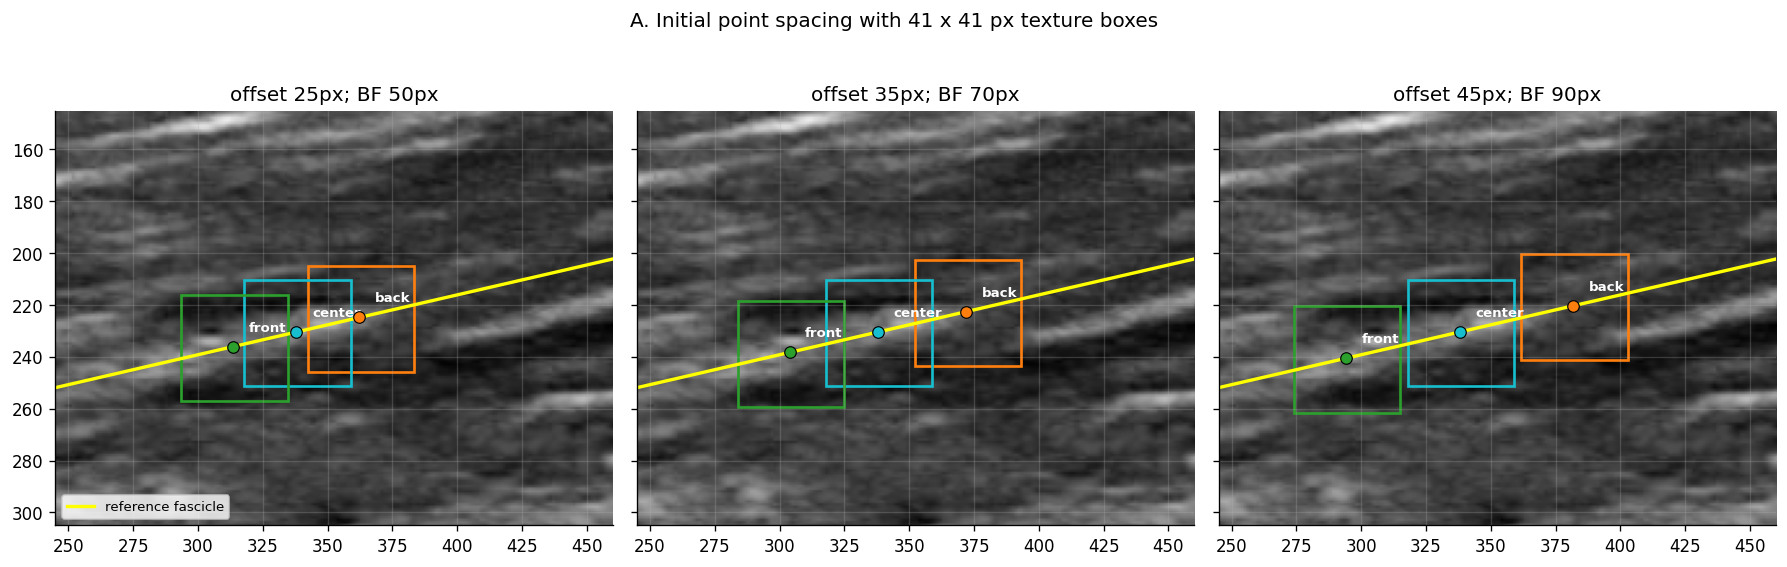

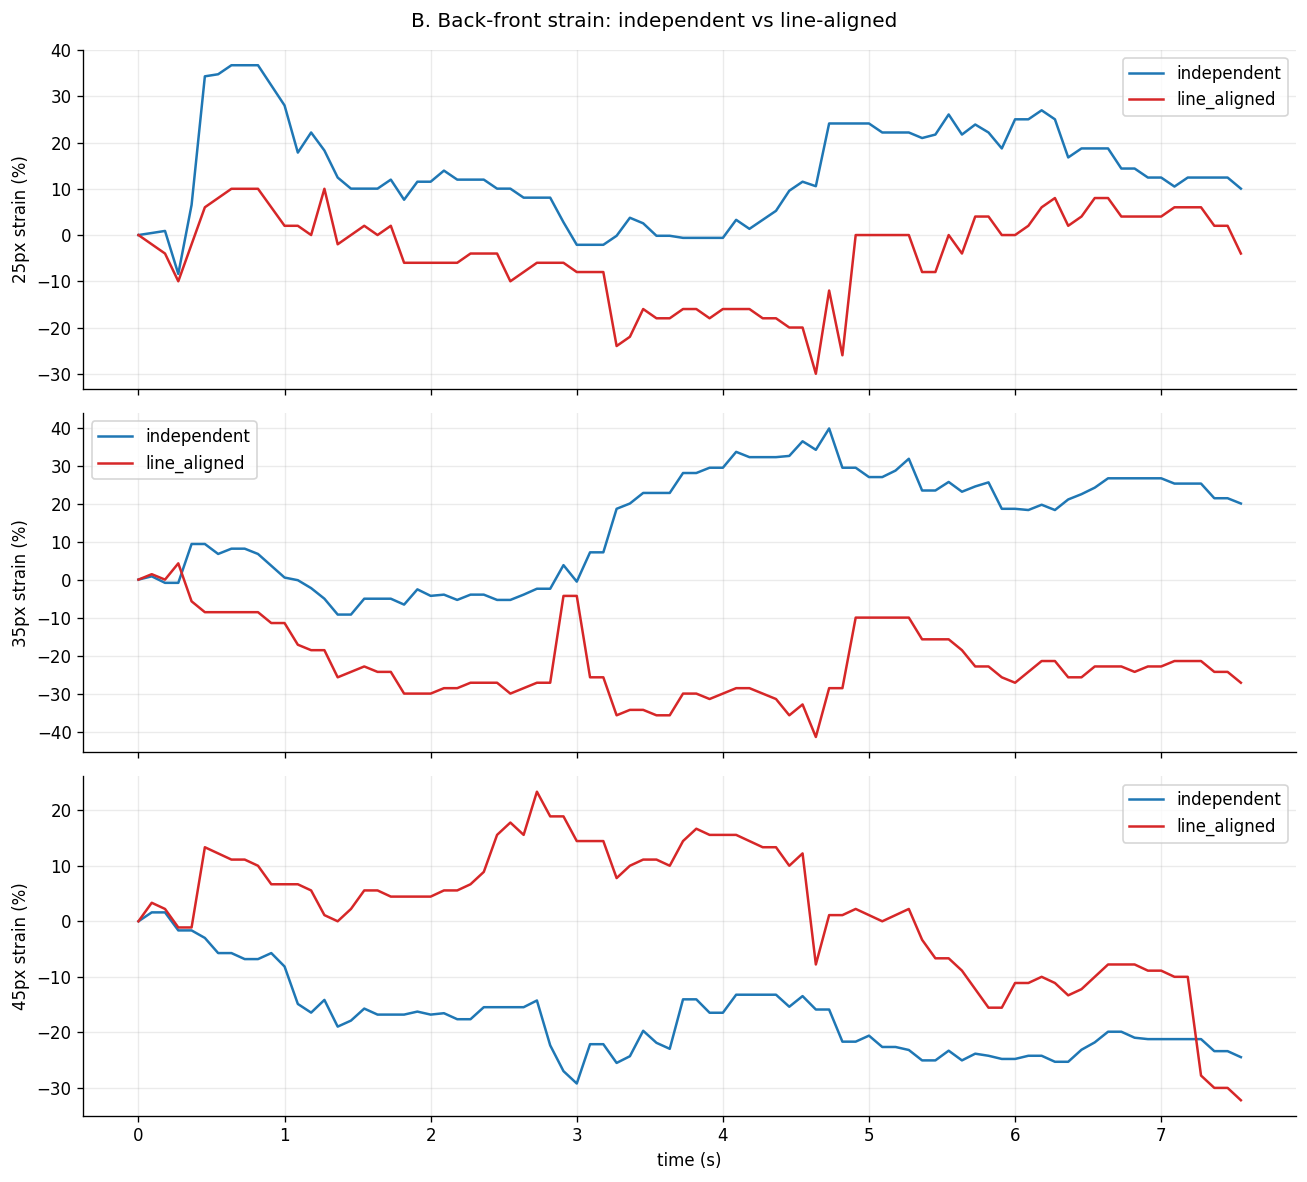

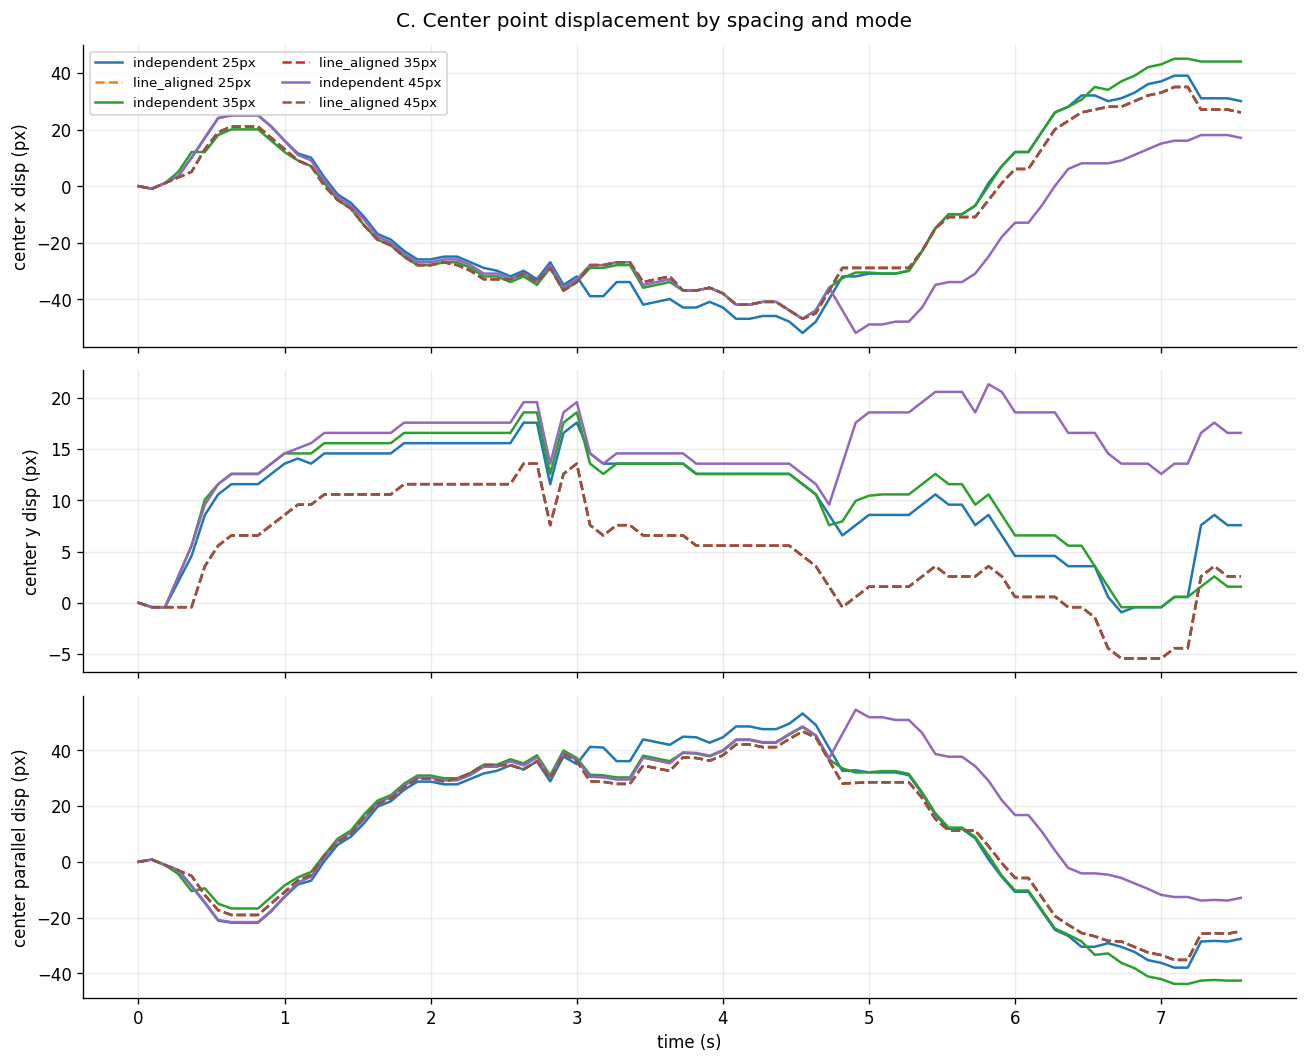

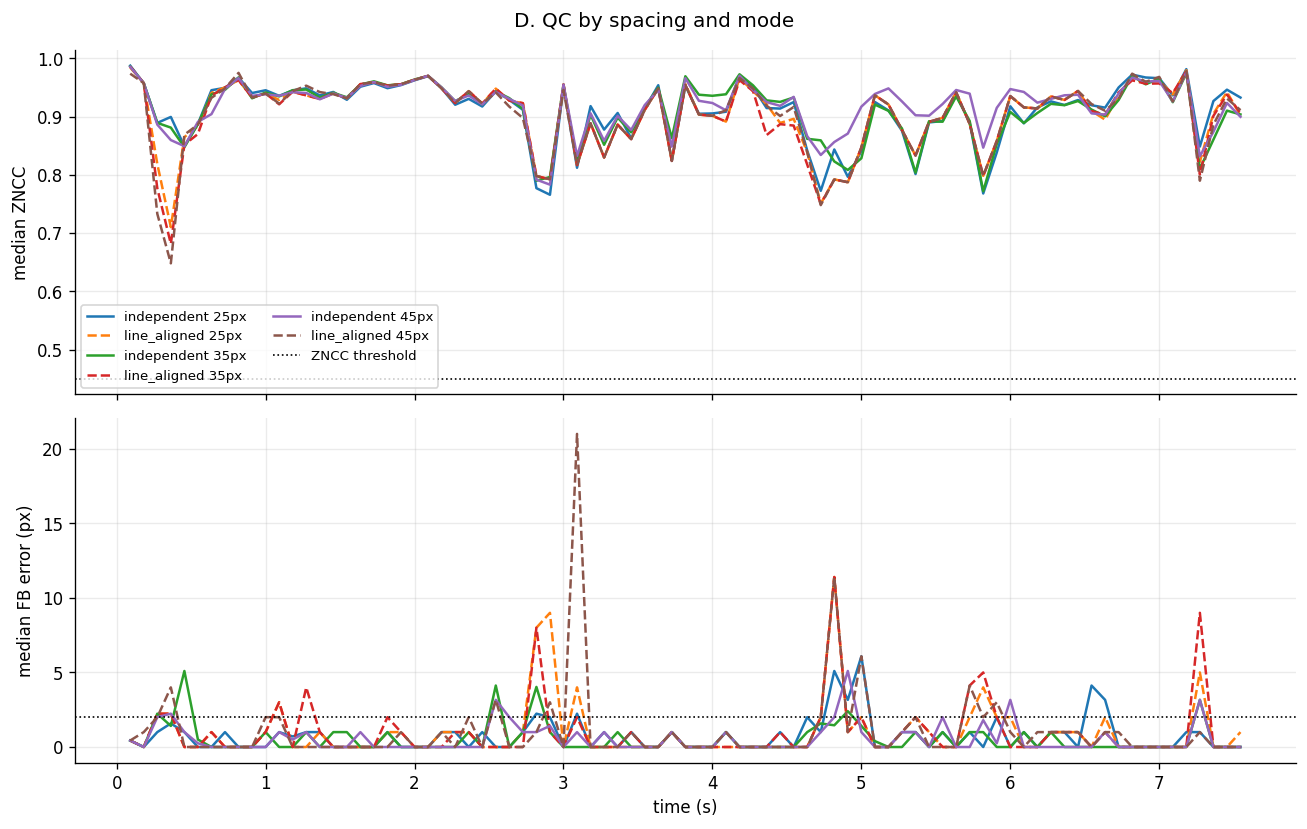

Saved figures:
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_spacing_line_alignment/figures/A_initial_spacing_boxes.png
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_spacing_line_alignment/figures/B_strain_independent_vs_line_aligned.png
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_spacing_line_alignment/figures/C_center_displacement_by_spacing_mode.png
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_spacing_line_alignment/figures/D_qc_by_spacing_mode.png


In [7]:
def plot_line(ax, line, color, label=None, linewidth=2.0, linestyle="-"):
    if line is None:
        return
    ax.plot([line[0], line[2]], [line[1], line[3]], color=color, linewidth=linewidth, linestyle=linestyle, label=label)


def draw_patch_box(ax, point, block_size, color, linewidth=1.4):
    half = int(block_size) // 2
    ax.add_patch(
        Rectangle(
            (float(point[0]) - half, float(point[1]) - half),
            int(block_size),
            int(block_size),
            fill=False,
            edgecolor=color,
            linewidth=linewidth,
        )
    )


fig, axes = plt.subplots(1, len(OFFSETS_PX), figsize=(15, 5), sharex=True, sharey=True)
for ax, offset in zip(axes, OFFSETS_PX):
    points = initial_points_by_offset[float(offset)]
    ax.imshow(frames[0], cmap="gray", vmin=0, vmax=255)
    plot_line(ax, fascicle_line0, color="yellow", label="reference fascicle", linewidth=2)
    for point_id in POINT_ORDER:
        point = points[point_id]
        draw_patch_box(ax, point, BOX_SIZE, POINT_COLORS[point_id], linewidth=1.6)
        ax.scatter(point[0], point[1], s=48, color=POINT_COLORS[point_id], edgecolor="black", linewidth=0.7, zorder=5)
        ax.text(point[0] + 6, point[1] - 6, point_id, color="white", fontsize=8, weight="bold")
    ax.set_title(f"offset {offset:.0f}px; BF {2*offset:.0f}px")
    ax.set_xlim(245, 460)
    ax.set_ylim(305, 145)
axes[0].legend(loc="lower left", fontsize=8)
fig.suptitle("A. Initial point spacing with 41 x 41 px texture boxes")
fig.tight_layout()
fig_a_path = FIG_DIR / "A_initial_spacing_boxes.png"
fig.savefig(fig_a_path)
plt.show()

fig, axes = plt.subplots(len(OFFSETS_PX), 1, figsize=(11, 10), sharex=True)
for ax, offset in zip(axes, OFFSETS_PX):
    for mode in ["independent", "line_aligned"]:
        strain = experiments[(mode, float(offset))]["strain"]
        ax.plot(time_s, strain["strain_back_front_percent"], label=mode, color=MODE_COLORS[mode])
    ax.set_ylabel(f"{offset:.0f}px strain (%)")
    ax.legend(loc="best")
axes[-1].set_xlabel("time (s)")
fig.suptitle("B. Back-front strain: independent vs line-aligned")
fig.tight_layout()
fig_b_path = FIG_DIR / "B_strain_independent_vs_line_aligned.png"
fig.savefig(fig_b_path)
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for offset in OFFSETS_PX:
    for mode, linestyle in [("independent", "-"), ("line_aligned", "--")]:
        df = experiments[(mode, float(offset))]["df"]
        center = df[df["point_id"] == "center"]
        axes[0].plot(center["time_s"], center["cumulative_dx"], linestyle=linestyle, label=f"{mode} {offset:.0f}px")
        axes[1].plot(center["time_s"], center["cumulative_dy"], linestyle=linestyle, label=f"{mode} {offset:.0f}px")
        axes[2].plot(center["time_s"], center["d_parallel_px"], linestyle=linestyle, label=f"{mode} {offset:.0f}px")
axes[0].set_ylabel("center x disp (px)")
axes[1].set_ylabel("center y disp (px)")
axes[2].set_ylabel("center parallel disp (px)")
axes[2].set_xlabel("time (s)")
axes[0].legend(loc="upper left", fontsize=8, ncol=2)
fig.suptitle("C. Center point displacement by spacing and mode")
fig.tight_layout()
fig_c_path = FIG_DIR / "C_center_displacement_by_spacing_mode.png"
fig.savefig(fig_c_path)
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for offset in OFFSETS_PX:
    for mode, linestyle in [("independent", "-"), ("line_aligned", "--")]:
        df = experiments[(mode, float(offset))]["df"]
        per_frame = df.groupby("frame").agg(time_s=("time_s", "first"), median_zncc=("zncc", "median"), median_fb=("forward_backward_error", "median")).reset_index()
        axes[0].plot(per_frame["time_s"], per_frame["median_zncc"], linestyle=linestyle, label=f"{mode} {offset:.0f}px")
        axes[1].plot(per_frame["time_s"], per_frame["median_fb"], linestyle=linestyle, label=f"{mode} {offset:.0f}px")
axes[0].axhline(CFG.zncc_low, color="black", linestyle=":", linewidth=1, label="ZNCC threshold")
axes[1].axhline(CFG.forward_backward_scale_px, color="black", linestyle=":", linewidth=1, label="FB threshold")
axes[0].set_ylabel("median ZNCC")
axes[1].set_ylabel("median FB error (px)")
axes[1].set_xlabel("time (s)")
axes[0].legend(loc="best", fontsize=8, ncol=2)
fig.suptitle("D. QC by spacing and mode")
fig.tight_layout()
fig_d_path = FIG_DIR / "D_qc_by_spacing_mode.png"
fig.savefig(fig_d_path)
plt.show()

print("Saved figures:")
for path in [fig_a_path, fig_b_path, fig_c_path, fig_d_path]:
    print(path)


## Overlay videos

This writes six videos: three spacings for normal independent tracking and three spacings for the line-aligned tracker.


In [8]:
MAKE_OVERLAY_VIDEOS = True


def gray_to_bgr(frame: np.ndarray) -> np.ndarray:
    arr = np.asarray(frame)
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    return cv2.cvtColor(arr, cv2.COLOR_GRAY2BGR) if arr.ndim == 2 else arr.copy()


def point_color_bgr(point_id: str) -> tuple[int, int, int]:
    return {"back": (0, 165, 255), "center": (255, 255, 0), "front": (0, 200, 0)}[point_id]


def mode_color_bgr(mode: str) -> tuple[int, int, int]:
    return {"independent": (255, 80, 20), "line_aligned": (40, 40, 255)}[mode]


def draw_patch_box_cv2(vis: np.ndarray, point: np.ndarray, box_size: int, color: tuple[int, int, int]) -> None:
    half = int(box_size) // 2
    x, y = np.rint(point).astype(int)
    cv2.rectangle(vis, (x - half, y - half), (x + half, y + half), color, 2, cv2.LINE_AA)


def write_overlay_video(mode: str, offset: float) -> Path:
    exp = experiments[(mode, float(offset))]
    tracking = exp["tracking"]
    strain = exp["strain"]
    safe_mode = mode.replace("_", "-")
    output_path = VIDEO_DIR / f"three_point_speckle_overlay_{safe_mode}_offset{int(offset)}px_box{BOX_SIZE}px.mp4"
    height, width = frames[0].shape[:2]
    video_fps = fps if np.isfinite(fps) and fps > 0 else 10.0
    writer = cv2.VideoWriter(str(output_path), cv2.VideoWriter_fourcc(*"mp4v"), video_fps, (width, height))
    if not writer.isOpened():
        raise RuntimeError(f"Could not open video writer for {output_path}")

    line_int = np.rint(fascicle_line0).astype(int)
    for frame_idx, frame in enumerate(frames):
        vis = gray_to_bgr(frame)
        cv2.line(vis, (line_int[0], line_int[1]), (line_int[2], line_int[3]), (0, 255, 255), 2, cv2.LINE_AA)
        current_positions = tracking["positions"][frame_idx]
        if mode == "line_aligned":
            back = current_positions[POINT_ORDER.index("back")]
            front = current_positions[POINT_ORDER.index("front")]
            cv2.line(vis, tuple(np.rint(back).astype(int)), tuple(np.rint(front).astype(int)), mode_color_bgr(mode), 2, cv2.LINE_AA)

        for point_idx, point_id in enumerate(POINT_ORDER):
            pts = tracking["positions"][: frame_idx + 1, point_idx, :]
            point_color = point_color_bgr(point_id)
            for a, b in zip(pts[:-1], pts[1:]):
                if np.all(np.isfinite(a)) and np.all(np.isfinite(b)):
                    cv2.line(vis, tuple(np.rint(a).astype(int)), tuple(np.rint(b).astype(int)), point_color, 2, cv2.LINE_AA)
            p = current_positions[point_idx]
            if np.all(np.isfinite(p)):
                draw_patch_box_cv2(vis, p, BOX_SIZE, mode_color_bgr(mode))
                cv2.circle(vis, tuple(np.rint(p).astype(int)), 6, point_color, -1, cv2.LINE_AA)
                cv2.circle(vis, tuple(np.rint(p).astype(int)), 7, (0, 0, 0), 1, cv2.LINE_AA)
                label_xy = tuple((np.rint(p).astype(int) + np.array([8, -8])).tolist())
                cv2.putText(vis, point_id, label_xy, cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 3, cv2.LINE_AA)
                cv2.putText(vis, point_id, label_xy, cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

        strain_value = float(strain.loc[frame_idx, "strain_back_front_percent"])
        text_lines = [
            f"{mode}  offset {offset:.0f}px  box {BOX_SIZE}px",
            f"frame {frame_idx:03d}  BF strain {strain_value:+.2f}%",
        ]
        for line_no, text in enumerate(text_lines):
            y = 32 + 30 * line_no
            cv2.putText(vis, text, (18, y), cv2.FONT_HERSHEY_SIMPLEX, 0.78, (0, 0, 0), 4, cv2.LINE_AA)
            cv2.putText(vis, text, (18, y), cv2.FONT_HERSHEY_SIMPLEX, 0.78, (255, 255, 255), 1, cv2.LINE_AA)
        writer.write(vis)
    writer.release()
    return output_path


overlay_paths = []
if MAKE_OVERLAY_VIDEOS:
    for offset in OFFSETS_PX:
        for mode in ["independent", "line_aligned"]:
            overlay_paths.append(write_overlay_video(mode, float(offset)))
    print("Saved overlay videos:")
    for path in overlay_paths:
        print(path)
else:
    print("Overlay videos skipped.")


Saved overlay videos:
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_spacing_line_alignment/overlays/three_point_speckle_overlay_independent_offset25px_box41px.mp4
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_spacing_line_alignment/overlays/three_point_speckle_overlay_line-aligned_offset25px_box41px.mp4
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_spacing_line_alignment/overlays/three_point_speckle_overlay_independent_offset35px_box41px.mp4
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_spacing_line_alignment/overlays/three_point_speckle_overlay_line-aligned_offset35px_box41px.mp4
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_spacing_line_alignment/overlays/three_point_speckle_overlay_independent_offset45px_box41px.mp4
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_spacing_line_alignment/overlays/three_point_speckle_overl

## Short conclusion


In [9]:
best_qc = summary_df.sort_values(["fallback_rows", "mean_zncc"], ascending=[True, False]).iloc[0]
best_strain = summary_df.sort_values("peak_abs_longitudinal_strain_percent").iloc[0]
aligned_rows = summary_df[summary_df["mode"] == "line_aligned"].copy()
independent_rows = summary_df[summary_df["mode"] == "independent"].copy()

display(
    Markdown(
        f'''
        - Texture box used here: **{BOX_SIZE} x {BOX_SIZE} px**.
        - Tested center-to-point offsets: **{", ".join(str(int(v)) for v in OFFSETS_PX)} px**.
        - Best QC by lowest fallback rows then highest mean ZNCC: **{best_qc["mode"]}, offset {best_qc["offset_px"]:.0f}px**.
        - Smallest peak absolute back-front strain: **{best_strain["mode"]}, offset {best_strain["offset_px"]:.0f}px**.

        The line-aligned mode forces the outer-point angle to remain the fascicle angle, using the center point as the anchor. That can make the overlay anatomically cleaner, but it also removes perpendicular information from the back/front points and makes the result more dependent on the center-point track.

        Outputs:

        - Tracking CSV: `{TRACKING_CSV_PATH}`
        - Summary CSV: `{SUMMARY_CSV_PATH}`
        - Figures: `{FIG_DIR}`
        - Overlay videos: `{VIDEO_DIR}`
        '''
    )
)



        - Texture box used here: **41 x 41 px**.
        - Tested center-to-point offsets: **25, 35, 45 px**.
        - Best QC by lowest fallback rows then highest mean ZNCC: **independent, offset 35px**.
        - Smallest peak absolute back-front strain: **independent, offset 45px**.

        The line-aligned mode forces the outer-point angle to remain the fascicle angle, using the center point as the anchor. That can make the overlay anatomically cleaner, but it also removes perpendicular information from the back/front points and makes the result more dependent on the center-point track.

        Outputs:

        - Tracking CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_spacing_line_alignment/spacing_line_alignment_tracking.csv`
        - Summary CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_spacing_line_alignment/spacing_line_alignment_summary.csv`
        - Figures: `/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_spacing_line_alignment/figures`
        - Overlay videos: `/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_spacing_line_alignment/overlays`
        